Parameters

In [1]:
import re
import sys
from glob import glob
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt

import scipy

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# --- Directory containing lfads_output_*.h5 (written by run_posterior_sampling at the
#     end of 2_run_pbt_kcEXP00H.py, inside the run's best_model/ folder). ---
# Leave as None to auto-pick the most recent run; or set explicitly to a best_model dir.
H5_DIR = None
if H5_DIR is None:
    # cands = sorted(Path('../runs').glob(
        # 'kcEXP00H_multisession_202606291751/pbt/*/*/best_model'))
    cands = sorted(Path('../runs').glob(
        'kcEXP00H_multisession_202607161710/pbt/*/*/best_model'))
    cands = [c for c in cands if list(c.glob('lfads_output_*.h5'))]
    assert cands, "No best_model with lfads_output_*.h5 found under ../runs"
    H5_DIR = cands[-1]
H5_DIR = Path(H5_DIR)
print("Using LFADS outputs from:", H5_DIR)

# --- Source xarray (.nc) files: needed only for per-trial condition labels (PSTHs / colors) ---
XARRAY_DIR = (
    '../datasets/xarray_files/'
)

# The 8 stimulus conditions (V=vision, O=odor, F=forward-walk; x = off).
COND_ORDER = ['VOF', 'VOx', 'VxF', 'Vxx', 'xOF', 'xOx', 'xxF', 'xxx']

Using LFADS outputs from: ../runs/kcEXP00H_multisession_202607161710/pbt/kcEXP00H_multisession_KC1pt2/260716/best_model


0.0 Util Fns

## 0.0 Load lfads outputs

In [2]:
def merge_train_valid(train_data, valid_data, train_inds, valid_inds):
    n_samples = len(train_data) + len(valid_data)
    merged = np.full((n_samples, *train_data.shape[1:]), np.nan, dtype=train_data.dtype)
    merged[train_inds] = train_data
    merged[valid_inds] = valid_data
    return merged

h5_paths = sorted(glob(str(H5_DIR / 'lfads_output_*.h5')))
assert h5_paths, f"No lfads_output_*.h5 in {H5_DIR}"

factors = {}
predicted_ts = {} #analogous to rates in tutorial


### claude gen below
flies = []                # h5 stems, one per fly
train_inds, valid_inds = {},{}
observed_ts, predicted_ts, factors = {}, {}, {}     # merged (n_trials, n_frames_per_trial, .) in original trial order
split = {}                # 'train'/'valid' arrays for the held-out R^2 metric
for path in h5_paths:
    fly = Path(path).stem.replace('lfads_output_lfads_', '')
    flies.append(fly)
    with h5py.File(path) as f:
        train_inds[fly] = f['train_inds'][()].astype(int) #training trial indices 
        valid_inds[fly] = f['valid_inds'][()].astype(int) #validation trial indices
        observed_ts[fly]   = merge_train_valid(f['train_recon_data'][()],
                                         f['valid_recon_data'][()],train_inds[fly], valid_inds[fly] )
        predicted_ts[fly]    = merge_train_valid(f['train_output_params'][()],
                                         f['valid_output_params'][()], train_inds[fly], valid_inds[fly] )
        factors[fly] = merge_train_valid(f['train_factors'][()],
                                         f['valid_factors'][()], train_inds[fly], valid_inds[fly] )
        # split[fly] = dict(
        #     train=(observed_ts[trf['train_recon_data'][()], f['train_output_params'][()]),
        #     valid=(f['valid_recon_data'][()], f['valid_output_params'][()]),
        # )
    print(f"  {fly}: observed_ts/pred {observed_ts[fly].shape}, factors {factors[fly].shape}")

n_fac = next(iter(factors.values())).shape[-1]
n_frames_per_trial = next(iter(factors.values())).shape[1]
print(f"\n{len(flies)} flies | n_factors = {n_fac} | n_frames_per_trial = {n_frames_per_trial}")

  H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)
  H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)
  H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)
  H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 66), factors (16, 1050, 50)
  H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP: observed_ts/pred (16, 1050, 67), factors (16, 1050, 50)

5 flies | n_factors = 50 | n_frames_per_trial = 1050


#### Util Fns

In [3]:
# Compact fly labels for plotting (e.g. 'H30003-005')
def _short(fly):
    m = re.search(r'H\d+-\d+', fly)
    return m.group() if m else fly
short = {fly: _short(fly) for fly in flies}
short


{'H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H30003-005',
 'H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H34006-007',
 'H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H35005-006',
 'H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H36006-007',
 'H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP': 'H37003-004'}

### understand variables

In [4]:
f=h5py.File(h5_paths[0])
fly_orig_data=f['train_output_params'][()]
fly_recon_data=f['train_recon_data'][()]

In [5]:
f.keys()

<KeysViewHDF5 ['readin_weight', 'readout_bias', 'train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_inds', 'train_output_params', 'train_recon_data', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_inds', 'valid_output_params', 'valid_recon_data', 'zscore_mean', 'zscore_std']>

## 0.1 remove baseline trials

In [6]:
# 1. grab the condition labels and save them in cond_by_ncstem (dict)
import xarray as xr

# condition labels keyed by .nc filename stem (e.g. 'H30003-005_..._DVAP')
cond_by_ncstem = {}
for p in sorted(glob(str(Path(XARRAY_DIR) / '*.nc'))):
    print(p)
    with xr.open_dataset(p) as ds:
        cond_by_ncstem[Path(p).stem] = \
            np.asarray(ds['condition'].values).reshape(-1).astype(str)


../datasets/xarray_files/H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
../datasets/xarray_files/H34006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
../datasets/xarray_files/H35005-006_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
../datasets/xarray_files/H36006-007_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc
../datasets/xarray_files/H37003-004_deltaF_Daqscans_BaseInterpPerRec_DVAP.nc


In [7]:
# 2. from cond_by_ncstem, remove the two baseline trials "xxx" 
# and name the output "CONDITIONS"
BASELINE_TRIALS=[0,9]
conditions = {}   # fly -> (n_trials,) str
for fly_name in flies:
    num_kept_trials = observed_ts[fly_name].shape[0]
    conditions_from_xarray = cond_by_ncstem[fly_name]
    if len(conditions_from_xarray) == num_kept_trials + len(BASELINE_TRIALS):
        conditions[fly_name] = np.delete(conditions_from_xarray, BASELINE_TRIALS)
    else:
        conditions[fly_name] = conditions_from_xarray


In [8]:
# conditions #dict with filename as key, array of 'VOx', "Vxx" etc.
# cond_by_ncstem #same as conditions but included the two baselines
# flies #array of string filenames
flies[0]

'H30003-005_deltaF_Daqscans_BaseInterpPerRec_DVAP'

In [9]:
fly = flies[0]                                   # H30003-005 -- same fly as section 3.2
factor = factors[fly]
conds = conditions[fly]

# Stimulus timing for THIS fly. Path.glob returns filesystem order, not sorted order, so
# index the .nc by name -- `list(...glob('*.nc'))[0]` was picking a different fly than `factor`.
ds = xr.load_dataset(Path(XARRAY_DIR) / f'{fly}.nc')
print('factors and stimulus timing both from', short[fly])

factors and stimulus timing both from H30003-005


In [10]:
#since odor_state_frame etc. were exported with wrong sizes from matlab to xarray
#we interpolate to the correct experimental frame size, then remove the baseline trials

complete_nframes = len(ds['trial']) * len(ds['time']) #total # frames per expt

def unsqueeze(name):
    v = ds[name].values
    return np.interp(np.linspace(0, len(v) - 1, complete_nframes), np.arange(len(v)), v)

odor_frames_flat = unsqueeze('odor_state_frame')
fw_frames_flat   = unsqueeze('fw_state_frame')
vis_frames_flat  = unsqueeze('vis_state_frame')

# create mask of frames belonging to the baseline trials, on the all-trials axis.
frame_idx = np.arange(len(odor_frames_flat))
n_t = len(ds['time'])
baseline_mask = np.zeros(len(frame_idx), bool)
for t in BASELINE_TRIALS:
    baseline_mask |= (frame_idx >= t * n_t) & (frame_idx < (t + 1) * n_t)

#remove baseline frames
keep_frames = ~baseline_mask
odor_trim = odor_frames_flat[keep_frames].astype(int) #otherwise would be type float64, problematic later on
fw_trim   = fw_frames_flat[keep_frames].astype(int)
vis_trim  = vis_frames_flat[keep_frames].astype(int)

In [11]:
# f=h5py.File(h5_paths[0]) 

In [12]:
fly = flies[0]                                   # H30003-005 -- same fly as section 3.2
factor = factors[fly]
conds = conditions[fly]

n_trials = len(conds)
x = np.arange(n_trials * n_frames_per_trial)
smask = {i: (x >= i * n_frames_per_trial) & (x < (i + 1) * n_frames_per_trial)
         for i in range(n_trials)}              # per-trial mask; also used in section 4

# One 0/1 indicator vector per condition over the concatenated-trial time axis.
# Keys land in order of first occurrence, matching trial order.
condition_vector = {}
for i_tr, cond in enumerate(conds):
    if cond not in condition_vector:
        condition_vector[cond] = np.zeros(len(x))
    condition_vector[cond] += smask[i_tr]

print({c: int(v.sum() // n_frames_per_trial) for c, v in condition_vector.items()},
      '= trials per condition')

{'VOx': 2, 'xOF': 2, 'VxF': 2, 'xxF': 2, 'Vxx': 2, 'xxx': 2, 'xOx': 2, 'VOF': 2} = trials per condition


### define conditions and assign numerical values

In [13]:
condition_numerical_values = dict()
for i, key in enumerate(condition_vector.keys()):
    condition_numerical_values[key] = i+1
condition_numerical_values

{'VOx': 1,
 'xOF': 2,
 'VxF': 3,
 'xxF': 4,
 'Vxx': 5,
 'xxx': 6,
 'xOx': 7,
 'VOF': 8}

In [14]:
condition_vector

{'VOx': array([1., 1., 1., ..., 0., 0., 0.]),
 'xOF': array([0., 0., 0., ..., 0., 0., 0.]),
 'VxF': array([0., 0., 0., ..., 1., 1., 1.]),
 'xxF': array([0., 0., 0., ..., 0., 0., 0.]),
 'Vxx': array([0., 0., 0., ..., 0., 0., 0.]),
 'xxx': array([0., 0., 0., ..., 0., 0., 0.]),
 'xOx': array([0., 0., 0., ..., 0., 0., 0.]),
 'VOF': array([0., 0., 0., ..., 0., 0., 0.])}

In [15]:
condition_vector_classes = dict()
for cond_name, vector in condition_vector.items():
    condition_vector_classes[cond_name] = condition_numerical_values[cond_name] * vector
condition_vector_classes

{'VOx': array([1., 1., 1., ..., 0., 0., 0.]),
 'xOF': array([0., 0., 0., ..., 0., 0., 0.]),
 'VxF': array([0., 0., 0., ..., 3., 3., 3.]),
 'xxF': array([0., 0., 0., ..., 0., 0., 0.]),
 'Vxx': array([0., 0., 0., ..., 0., 0., 0.]),
 'xxx': array([0., 0., 0., ..., 0., 0., 0.]),
 'xOx': array([0., 0., 0., ..., 0., 0., 0.]),
 'VOF': array([0., 0., 0., ..., 0., 0., 0.])}

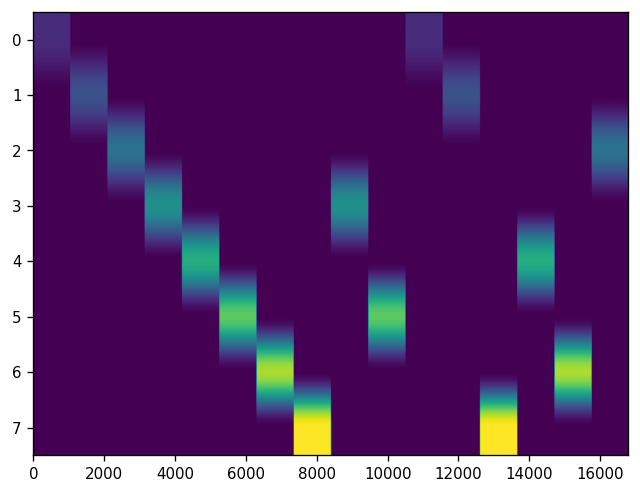

In [16]:
plt.imshow(list(condition_vector_classes.values()), aspect='auto')

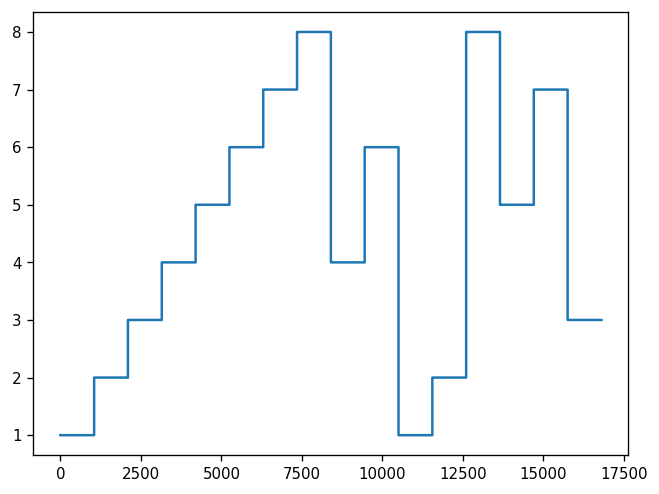

In [17]:
plt.step(x = np.arange(0,16800), y=np.array(list(condition_vector_classes.values())).sum(axis=0))

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split

### logistic regression- proof of principle

In [ ]:
#example to find most freq value in an array
# a = np.array([0,1,1,2])
# counts = np.bincount(a)
# most_frequent_value = np.argmax(counts)

run logistic regression, then divide y_pred into trial chunks, find the most frequent numerical values within each chunk. This is bc it is difficult to decode when nothing is happening (no stim response)- nothing to decode 

In [ ]:
X = factors[fly].reshape(-1, n_fac) #keep n_fac, do whatever is needed to get there (-1)
# predicted_cond = {}
Y= np.array(list(condition_vector_classes.values())).sum(axis=0)
reg = LogisticRegression(class_weight='balanced', max_iter=10000) #set up instance of class
reg.fit(X,Y)

y_pred = reg.predict(X)
y_pred.shape
# predicted_cond[cond_name] = y_pred
print(f"Logistic Regression model accuracy: {metrics.accuracy_score(Y, y_pred) * 100:.4f}%")


Logistic Regression model accuracy: 71.8274%


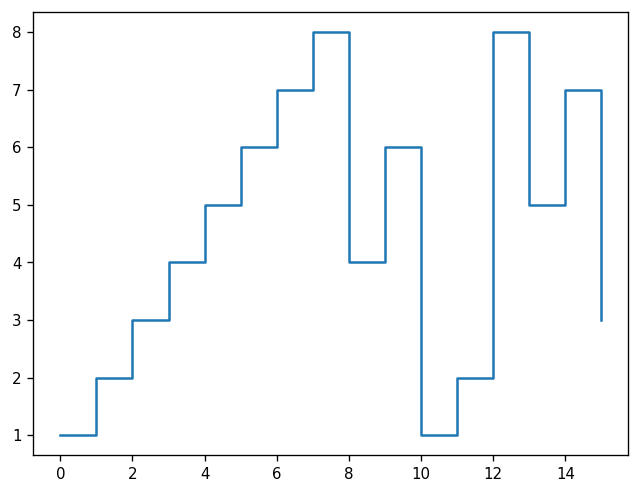

In [64]:
predicted_condition=[]
for i in range(16):
    vals, counts=np.unique(y_pred.reshape(16,1050)[i], return_counts=True)
    predicted_condition.append(vals[np.argmax(counts)])

plt.step(np.arange(16), predicted_condition, where='post')

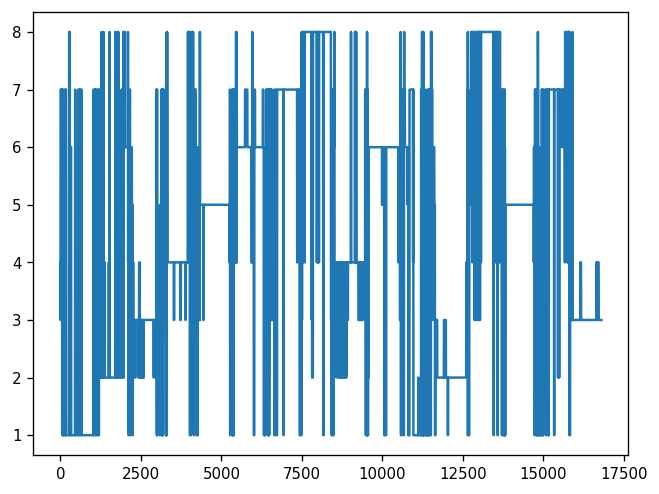

In [65]:
#problematic if we just take the values at every frame
plt.plot(y_pred)

### logistic regression + train vs. split data

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split

# factors[fly].shape #numTrials, numFramesPerTrial, numFactors
X = factors[fly].reshape(-1, n_fac) #keep n_fac, do whatever is needed to get there (-1)
Y= np.array(list(condition_vector_classes.values())).sum(axis=0)


In [ ]:
# reshape X & Y to have trial structure for defining train vs. split data
X_trial = X.reshape(16,1050,50) #sort X into trial, trialframes, factors
Y_trial = Y.reshape(16,-1)

# manually define train vs. test via rand int of trial indices
rng = np.random.default_rng(0) #seeding
perm = rng.permutation(16)
train_trial_ind, test_trial_ind = perm[:12], perm[12:]

X_train = X_trial[train_trial_ind,:]
Y_train = Y_trial[train_trial_ind]
print(f"X_train shaped {X_train.shape}; Y_train shaped {Y_train.shape}")


X_test = X_trial[test_trial_ind,:]
Y_test = Y_trial[test_trial_ind]
print(f"X_test shaped {X_test.shape}; Y_test shaped {Y_test.shape}")



X_train shaped (12, 1050, 50); Y_train shaped (12, 1050)
X_test shaped (4, 1050, 50); Y_test shaped (4, 1050)


In [ ]:
reg = LogisticRegression(class_weight='balanced', max_iter=1000) #set up instance of class
reg.fit(X_train.reshape(-1,50),Y_train.flatten()) #cannot simply flatten X_train bc we need it 2-dim (flattened T, factors)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [118]:
y_pred = reg.predict(X_test.reshape(-1,50))
y_pred.shape
# predicted_cond[cond_name] = y_pred
print(f"Logistic Regression model accuracy: {metrics.accuracy_score(Y_test.flatten(), y_pred) * 100:.4f}%")

Logistic Regression model accuracy: 13.5238%


In [126]:
test_trial_ind

array([13,  8,  1, 15])

In [127]:
Y_trial[test_trial_ind]

array([[5., 5., 5., ..., 5., 5., 5.],
       [4., 4., 4., ..., 4., 4., 4.],
       [2., 2., 2., ..., 2., 2., 2.],
       [3., 3., 3., ..., 3., 3., 3.]])

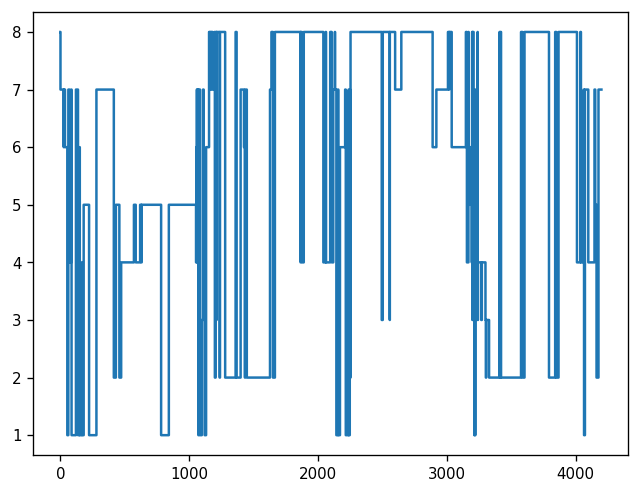

In [125]:
plt.step(np.arange(y_pred.shape[0]),y_pred)
# y_pred.shape

In [ ]:


predicted_condition=[]
for i in range(16):
    vals, counts=np.unique(y_pred.reshape(16,1050)[i], return_counts=True)
    predicted_condition.append(vals[np.argmax(counts)])

plt.step(np.arange(16), predicted_condition, where='post')

ValueError: Found input variables with inconsistent numbers of samples: [16800, 4200]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split

# factors[fly].shape #numTrials, numFramesPerTrial, numFactors
X = factors[fly].reshape(-1, n_fac) #keep n_fac, do whatever is needed to get there (-1)
Y= np.array(list(condition_vector_classes.values())).sum(axis=0)


X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.4, random_state=1, shuffle=False)


predicted_cond = {}
for cond_name, Y in zip(('Odor', 'FW', 'Vis'),(odor_trim, fw_trim, vis_trim)):


    X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.4, random_state=1, shuffle=False)


    reg_odor = LogisticRegression(class_weight='balanced', max_iter=1000) #set up instance of class
    reg_odor.fit(X_train,Y_train)

    y_pred = reg_odor.predict(X_test)
    predicted_cond[cond_name] = y_pred
    print(f"Logistic Regression model accuracy: {metrics.accuracy_score(Y_test, y_pred) * 100:.2f}%")


# logistic regression on individual stimulus; we see high model accuracy but the predictions are all wrong (see figures)
# Atle: known problem in ML when one binary class dominates- in this case mostly 0's
# supposedly class_weight = 'balanced' counters this but it clearly doesn't in this case
predicted_cond = {}

Y = fw_trim
cond_name='FW'

reg = LogisticRegression(class_weight='balanced', max_iter=1000) #set up instance of class
reg.fit(X,Y)

y_pred = reg.predict(X)
predicted_cond[cond_name] = y_pred
print(f"Logistic Regression model accuracy: {metrics.accuracy_score(Y, y_pred) * 100:.2f}%")
plt.plot(predicted_cond[cond_name],'r')
plt.plot(Y_test,'b')
plt.title(cond_name)

Y = odor_trim
cond_name='Odor'

reg = LogisticRegression(class_weight='balanced', max_iter=1000) #set up instance of class
reg.fit(X,Y)

y_pred = reg.predict(X)
predicted_cond[cond_name] = y_pred
print(f"Logistic Regression model accuracy: {metrics.accuracy_score(Y, y_pred) * 100:.2f}%")
plt.figure()
plt.plot(predicted_cond[cond_name],'r')
plt.plot(Y_test,'b')
plt.title(cond_name)

Y = vis_trim
cond_name='Vis'

reg = LogisticRegression(class_weight='balanced', max_iter=1000) #set up instance of class
reg.fit(X,Y)

y_pred = reg.predict(X)
predicted_cond[cond_name] = y_pred
print(f"Logistic Regression model accuracy: {metrics.accuracy_score(Y, y_pred) * 100:.2f}%")
plt.figure()
plt.plot(predicted_cond[cond_name],'r')
plt.plot(Y_test,'b')
plt.title(cond_name)


#### logistic regression on one single sitmulus matrix

#### (retired) logistic regression on single modality- DOESN'T WORK

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split

# factors[fly].shape #numTrials, numFramesPerTrial, numFactors
X = factors[fly].reshape(-1, n_fac) #keep n_fac, do whatever is needed to get there (-1)
predicted_cond = {}
for cond_name, Y in zip(('Odor', 'FW', 'Vis'),(odor_trim, fw_trim, vis_trim)):


    X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.4, random_state=1, shuffle=False)


    reg_odor = LogisticRegression(class_weight='balanced', max_iter=1000) #set up instance of class
    reg_odor.fit(X_train,Y_train)

    y_pred = reg_odor.predict(X_test)
    predicted_cond[cond_name] = y_pred
    print(f"Logistic Regression model accuracy: {metrics.accuracy_score(Y_test, y_pred) * 100:.2f}%")



Logistic Regression model accuracy: 96.38%
Logistic Regression model accuracy: 82.90%
Logistic Regression model accuracy: 74.12%


Logistic Regression model accuracy: 98.71%
Logistic Regression model accuracy: 97.27%
Logistic Regression model accuracy: 76.70%


Text(0.5, 1.0, 'Vis')

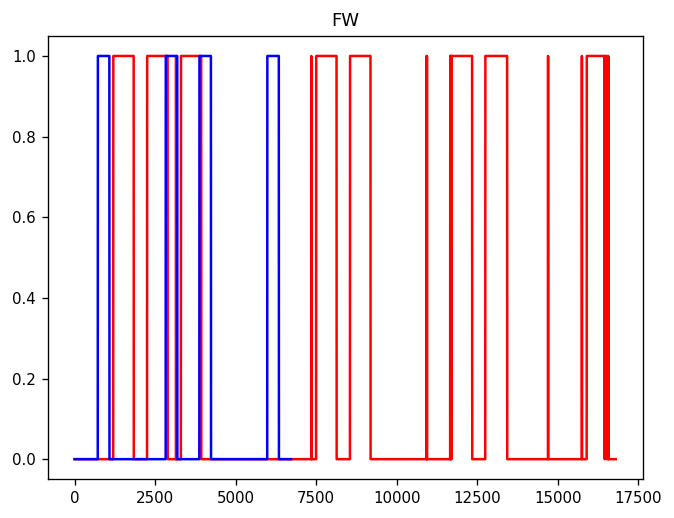

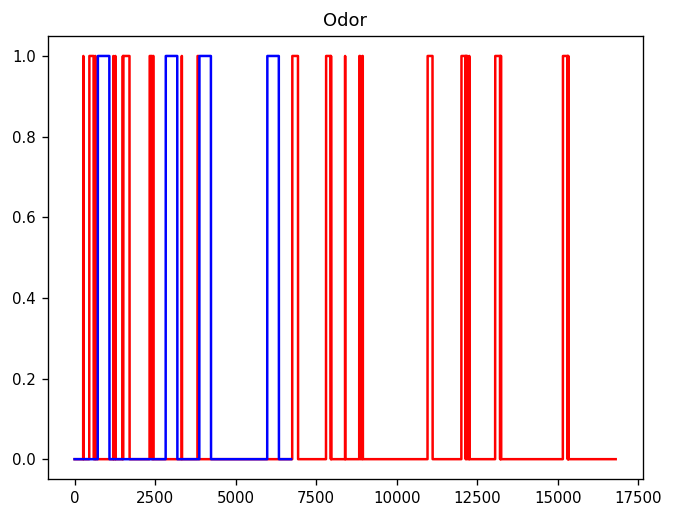

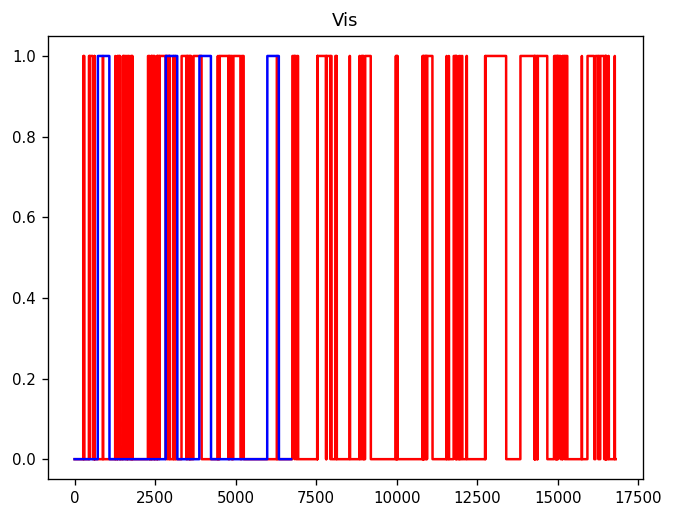

In [29]:
# logistic regression on individual stimulus; we see high model accuracy but the predictions are all wrong (see figures)
# Atle: known problem in ML when one binary class dominates- in this case mostly 0's
# supposedly class_weight = 'balanced' counters this but it clearly doesn't in this case
predicted_cond = {}

Y = fw_trim
cond_name='FW'

reg = LogisticRegression(class_weight='balanced', max_iter=1000) #set up instance of class
reg.fit(X,Y)

y_pred = reg.predict(X)
predicted_cond[cond_name] = y_pred
print(f"Logistic Regression model accuracy: {metrics.accuracy_score(Y, y_pred) * 100:.2f}%")
plt.plot(predicted_cond[cond_name],'r')
plt.plot(Y_test,'b')
plt.title(cond_name)

Y = odor_trim
cond_name='Odor'

reg = LogisticRegression(class_weight='balanced', max_iter=1000) #set up instance of class
reg.fit(X,Y)

y_pred = reg.predict(X)
predicted_cond[cond_name] = y_pred
print(f"Logistic Regression model accuracy: {metrics.accuracy_score(Y, y_pred) * 100:.2f}%")
plt.figure()
plt.plot(predicted_cond[cond_name],'r')
plt.plot(Y_test,'b')
plt.title(cond_name)

Y = vis_trim
cond_name='Vis'

reg = LogisticRegression(class_weight='balanced', max_iter=1000) #set up instance of class
reg.fit(X,Y)

y_pred = reg.predict(X)
predicted_cond[cond_name] = y_pred
print(f"Logistic Regression model accuracy: {metrics.accuracy_score(Y, y_pred) * 100:.2f}%")
plt.figure()
plt.plot(predicted_cond[cond_name],'r')
plt.plot(Y_test,'b')
plt.title(cond_name)


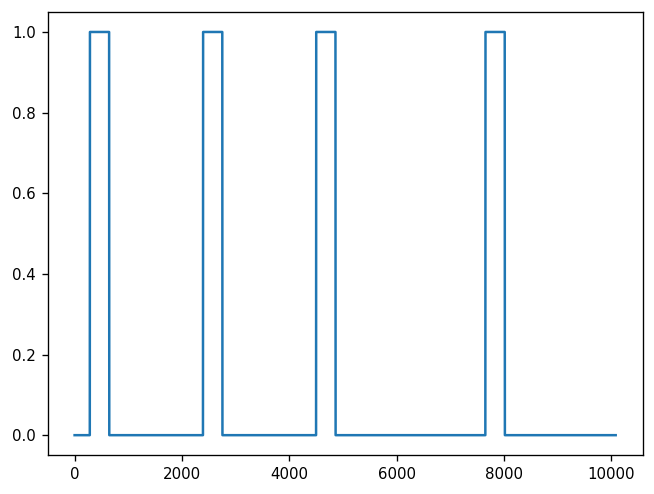

In [30]:
plt.plot(Y_train)

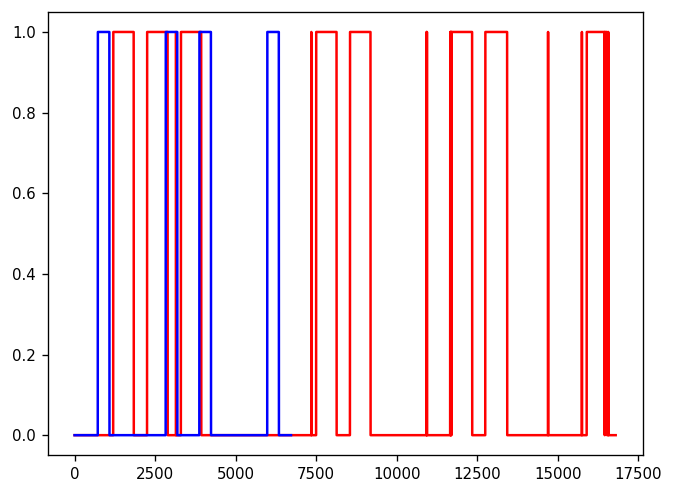

In [31]:
plt.plot(predicted_cond['FW'],'r')
plt.plot(Y_test,'b')

#### understanding logistic regression 

In [32]:
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split

digits = datasets.load_digits()
x = digits.data #shape 1797,64
y = digits.target #shape 1797


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

reg = LogisticRegression(max_iter=10000, random_state=0)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

print(f"Logistic Regression model accuracy: {metrics.accuracy_score(y_test, y_pred) * 100:.2f}%")

ValueError: Found input variables with inconsistent numbers of samples: [16800, 1797]

In [ ]:
(X_test @ reg.coef_.T)[0] #for each row, this returns a form of probability; the max prob = we say this row should be digit 1 etc.

array([-6.51375141, 13.94222165,  2.1205643 , -8.9882331 , -0.44548271,
       -5.88777485,  1.23011239,  1.62303514,  9.60462409, -6.6853155 ])

In [ ]:
np.argmax(X_test @ reg.coef_.T + reg.intercept_, axis=1) #this is how Y_pred is calculated

array([1, 5, 0, 7, 1, 0, 6, 1, 5, 4, 9, 2, 7, 8, 4, 6, 9, 3, 7, 4, 7, 4,
       8, 6, 0, 9, 6, 1, 3, 7, 5, 9, 8, 3, 2, 8, 8, 1, 1, 0, 7, 9, 0, 0,
       8, 7, 2, 7, 4, 3, 4, 3, 4, 0, 4, 7, 0, 5, 5, 5, 2, 1, 7, 0, 5, 1,
       8, 3, 3, 4, 0, 3, 7, 4, 3, 4, 2, 9, 7, 3, 2, 5, 3, 4, 1, 5, 5, 2,
       1, 2, 2, 2, 2, 7, 0, 8, 1, 7, 4, 2, 3, 8, 2, 3, 3, 0, 2, 9, 5, 2,
       3, 2, 8, 1, 1, 9, 1, 2, 0, 4, 8, 5, 4, 4, 7, 6, 7, 6, 6, 1, 7, 5,
       6, 3, 8, 3, 7, 1, 8, 5, 3, 4, 7, 8, 5, 0, 6, 0, 6, 3, 7, 6, 5, 6,
       2, 2, 2, 3, 0, 7, 6, 5, 6, 4, 1, 0, 6, 0, 6, 4, 0, 9, 3, 5, 1, 2,
       3, 1, 9, 0, 7, 6, 2, 9, 3, 5, 3, 4, 6, 3, 3, 7, 4, 9, 2, 7, 6, 1,
       6, 8, 4, 0, 3, 1, 0, 9, 9, 9, 0, 1, 8, 6, 8, 0, 9, 5, 9, 8, 2, 3,
       5, 3, 0, 8, 7, 4, 0, 3, 3, 3, 6, 3, 3, 2, 9, 1, 6, 9, 0, 4, 2, 2,
       7, 9, 1, 6, 7, 6, 3, 9, 1, 8, 3, 4, 0, 6, 4, 8, 5, 3, 6, 3, 1, 4,
       0, 4, 4, 8, 7, 9, 1, 5, 2, 7, 0, 9, 0, 4, 4, 0, 1, 0, 6, 4, 2, 8,
       5, 0, 2, 6, 0, 1, 8, 2, 0, 9, 5, 6, 2, 0, 5,

In [ ]:
y_pred

array([1, 5, 0, 7, 1, 0, 6, 1, 5, 4, 9, 2, 7, 8, 4, 6, 9, 3, 7, 4, 7, 4,
       8, 6, 0, 9, 6, 1, 3, 7, 5, 9, 8, 3, 2, 8, 8, 1, 1, 0, 7, 9, 0, 0,
       8, 7, 2, 7, 4, 3, 4, 3, 4, 0, 4, 7, 0, 5, 5, 5, 2, 1, 7, 0, 5, 1,
       8, 3, 3, 4, 0, 3, 7, 4, 3, 4, 2, 9, 7, 3, 2, 5, 3, 4, 1, 5, 5, 2,
       1, 2, 2, 2, 2, 7, 0, 8, 1, 7, 4, 2, 3, 8, 2, 3, 3, 0, 2, 9, 5, 2,
       3, 2, 8, 1, 1, 9, 1, 2, 0, 4, 8, 5, 4, 4, 7, 6, 7, 6, 6, 1, 7, 5,
       6, 3, 8, 3, 7, 1, 8, 5, 3, 4, 7, 8, 5, 0, 6, 0, 6, 3, 7, 6, 5, 6,
       2, 2, 2, 3, 0, 7, 6, 5, 6, 4, 1, 0, 6, 0, 6, 4, 0, 9, 3, 5, 1, 2,
       3, 1, 9, 0, 7, 6, 2, 9, 3, 5, 3, 4, 6, 3, 3, 7, 4, 9, 2, 7, 6, 1,
       6, 8, 4, 0, 3, 1, 0, 9, 9, 9, 0, 1, 8, 6, 8, 0, 9, 5, 9, 8, 2, 3,
       5, 3, 0, 8, 7, 4, 0, 3, 3, 3, 6, 3, 3, 2, 9, 1, 6, 9, 0, 4, 2, 2,
       7, 9, 1, 6, 7, 6, 3, 9, 1, 8, 3, 4, 0, 6, 4, 8, 5, 3, 6, 3, 1, 4,
       0, 4, 4, 8, 7, 9, 1, 5, 2, 7, 0, 9, 0, 4, 4, 0, 1, 0, 6, 4, 2, 8,
       5, 0, 2, 6, 0, 1, 8, 2, 0, 9, 5, 6, 2, 0, 5,